#  Price Elasticity (PE) + TPRC Estimation via Double Machine Learning
### Dataset: [Kaggle Avocado Prices](https://www.kaggle.com/datasets/neuromusic/avocado-prices)

---

**R² fixes applied (full revision):**

| # | Root Cause | Fix |
|---|-----------|-----|
| 1 | City price gap (Houston \$1 vs SF \$1.75) | Geographic entity fixed effects (onehot / target) |
| 2 | Asymmetric harvest peaks | Multi-harmonic Fourier seasonality (3 harmonics) |
| 3 | Online/Offline different price worlds | Channel-specific price nuisance model |
| 4 | Price outlier spikes | HuberRegressor option for price first-stage |
| **5** | **Pre-demeaning removes signal before nuisance model sees it** | **Use raw lnP/lnQ; let outlet dummies in X absorb city-level differences** |


## 1. Setup — Imports & Config

In [1]:
import warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import RidgeCV, HuberRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)
print('✓  All imports successful')


✓  All imports successful


In [2]:
CONFIG = {
    'data_path'        : '/Users/asamitakeuchi/Downloads/Data/avocado.csv',
    'n_folds'          : 5,
    'min_weeks'        : 10,
    'min_price_pts'    : 3,
    'discount_thresh'  : 0.03,
    'max_discount_eps' : 4,
    'min_discount_obs' : 2,
    'r2_min'           : 0.05,
    'ci_width_max'     : 5.0,
    'aggregate_regions': {
        'TotalUS', 'Total U.S.',
        'West', 'Midsouth', 'Southeast', 'Northeast',
        'SouthCentral', 'South Central',
        'GreatLakes', 'Great Lakes', 'Plains',
    },
    'plu_cols'    : ['4046', '4225', '4770'],
    'channel_map' : {'conventional': 'Offline', 'organic': 'Online'},

    # ── Fix 1: Geographic entity fixed effects ────────────────────────────
    # 'onehot' = one dummy per city (default) | 'target' = mean(lnP) encoding
    'geo_encoding'            : 'onehot',

    # ── Fix 2: Fourier seasonality harmonics ──────────────────────────────
    # n=3 captures main harvest cycle + secondary supply pulses
    'fourier_harmonics'       : 3,

    # ── Fix 3: Channel-specific price nuisance model ──────────────────────
    'channel_specific_models' : True,

    # ── Fix 4: Independent model backends ────────────────────────────────
    # price_model: 'gbm' | 'huber' | 'ridge' | 'rf'
    'price_model'             : 'gbm',
    'qty_model'               : 'gbm',
    'huber_epsilon'           : 1.35,
    'huber_max_iter'          : 500,

    # ── Fix 5: Use raw log-price (no pre-demeaning) ───────────────────────
    # ROOT CAUSE of r2_price ≈ 0.003:
    # Pre-demeaning lnP by (item, outlet) removes ALL between-outlet price
    # variation before the nuisance model runs. The model then tries to predict
    # the tiny within-outlet residuals (~3 distinct price levels per outlet)
    # which have almost no predictable signal → r2 ≈ 0.
    #
    # With 'demean_mode' = 'none': use raw lnP/lnQ as treatment/outcome.
    #   The nuisance model E[lnP | X] absorbs city-level differences via outlet
    #   dummies in X — same result as demeaning but the model SEES the variation.
    #
    # With 'demean_mode' = 'time': demean by week×item (remove time shocks)
    #   rather than by outlet. Preserves outlet-level price variation for nuisance.
    #
    # With 'demean_mode' = 'outlet': original behaviour (pre-demean by outlet).
    #   Correct in theory but only if outlet variation is NOT in X. Since we
    #   include outlet dummies in X this is double-removing the same variation.
    'demean_mode'             : 'none',   # 'none' | 'time' | 'outlet'
}

print('✓  Config loaded')
print(f"   geo_encoding            : {CONFIG['geo_encoding']}    (Fix 1)")
print(f"   fourier_harmonics       : {CONFIG['fourier_harmonics']}               (Fix 2)")
print(f"   channel_specific_models : {CONFIG['channel_specific_models']}     (Fix 3)")
print(f"   price_model             : {CONFIG['price_model']}              (Fix 4)")
print(f"   demean_mode             : {CONFIG['demean_mode']}            (Fix 5 ← key)")


✓  Config loaded
   geo_encoding            : onehot    (Fix 1)
   fourier_harmonics       : 3               (Fix 2)
   channel_specific_models : True     (Fix 3)
   price_model             : gbm              (Fix 4)
   demean_mode             : none            (Fix 5 ← key)


In [3]:
# ── Model factory (Fix 4): independent price & qty backends ─────────────────
def make_price_model():
    k = CONFIG['price_model']
    if k == 'gbm':
        return GradientBoostingRegressor(
            n_estimators=150, max_depth=3, learning_rate=0.05,
            subsample=0.8, random_state=42)
    elif k == 'huber':
        # Fix 4 recommended: robust to outlier price spikes in EDA boxplots
        return HuberRegressor(
            epsilon=CONFIG['huber_epsilon'],
            max_iter=CONFIG['huber_max_iter'], alpha=0.0001)
    elif k == 'ridge':
        return RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0])
    elif k == 'rf':
        return RandomForestRegressor(
            n_estimators=200, max_depth=5, min_samples_leaf=5, random_state=42)
    else:
        raise ValueError(f"Unknown price_model '{k}'")

def make_qty_model():
    k = CONFIG['qty_model']
    if k == 'gbm':
        return GradientBoostingRegressor(
            n_estimators=150, max_depth=3, learning_rate=0.05,
            subsample=0.8, random_state=42)
    elif k == 'ridge':
        return RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0])
    elif k == 'rf':
        return RandomForestRegressor(
            n_estimators=200, max_depth=5, min_samples_leaf=5, random_state=42)
    else:
        raise ValueError(f"Unknown qty_model '{k}'")

print(f'✓  Model factory: price={CONFIG["price_model"]} ({type(make_price_model()).__name__}), '
      f'qty={CONFIG["qty_model"]} ({type(make_qty_model()).__name__})')


✓  Model factory: price=gbm (GradientBoostingRegressor), qty=gbm (GradientBoostingRegressor)


---
## 2. Load & Validate Raw Data

We check the file exists, columns match the expected Kaggle schema, and
flag any data quality issues **before** any transformations run.

In [4]:
# ── 2A. Load ──────────────────────────────────────────────────────────────────
EXPECTED_COLS = {
    "Date", "AveragePrice", "Total Volume",
    "4046", "4225", "4770", "Total Bags",
    "Small Bags", "Large Bags", "XLarge Bags",
    "type", "year", "region",
}

data_path = Path(CONFIG["data_path"])

if not data_path.exists():
    raise FileNotFoundError(
        f"\n\n  ❌  avocado.csv not found at: {data_path.resolve()}\n"
        "  Download from: https://www.kaggle.com/datasets/neuromusic/avocado-prices\n"
        "  and place avocado.csv in the same folder as this notebook.\n"
    )

df_raw = pd.read_csv(data_path)
print(f"✓  Loaded {len(df_raw):,} rows × {df_raw.shape[1]} columns")
df_raw.head(3)

✓  Loaded 18,249 rows × 14 columns


,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.3300,64236.6200,1036.7400,54454.8500,48.1600,8696.8700,8603.6200,93.2500,0.0000,conventional,2015,Albany
1,1,2015-12-20,1.3500,54876.9800,674.2800,44638.8100,58.3300,9505.5600,9408.0700,97.4900,0.0000,conventional,2015,Albany
2,2,2015-12-13,0.9300,118220.2200,794.7000,109149.6700,130.5000,8145.3500,8042.2100,103.1400,0.0000,conventional,2015,Albany


In [5]:
# ── 2B. Schema check ──────────────────────────────────────────────────────────
missing_cols = EXPECTED_COLS - set(df_raw.columns)
if missing_cols:
    raise ValueError(f"Missing expected columns: {missing_cols}")
print("✓  All expected columns present")

# ── 2C. Quality checks ────────────────────────────────────────────────────────
issues = []

# Missing values
for col in ["Date", "AveragePrice", "4046", "4225", "4770", "type", "region"]:
    n = df_raw[col].isna().sum()
    if n: issues.append(f"  ⚠  '{col}' has {n} missing values")

# Non-positive prices
n_bad_price = (pd.to_numeric(df_raw["AveragePrice"], errors="coerce") <= 0).sum()
if n_bad_price: issues.append(f"  ⚠  {n_bad_price} rows with price ≤ 0")

# Duplicate rows
n_dupes = df_raw.duplicated(subset=["Date", "region", "type"]).sum()
if n_dupes: issues.append(f"  ⚠  {n_dupes} duplicate (Date, region, type) rows")

# Aggregate regions
agg_found = CONFIG["aggregate_regions"] & set(df_raw["region"].dropna())
if agg_found: issues.append(f"  ℹ  Aggregate regions found (will be removed): {agg_found}")

if issues:
    print("Validation warnings (all recoverable):")
    for i in issues: print(i)
else:
    print("✓  No data quality issues found")

print(f"\nUnique regions : {df_raw['region'].nunique()}")
print(f"Unique types   : {df_raw['type'].unique()}")
print(f"Year range     : {df_raw['year'].min()} – {df_raw['year'].max()}")

✓  All expected columns present
Validation warnings (all recoverable):
  ℹ  Aggregate regions found (will be removed): {'Southeast', 'Plains', 'West', 'Northeast', 'SouthCentral', 'Midsouth', 'TotalUS', 'GreatLakes'}

Unique regions : 54
Unique types   : <StringArray>
['conventional', 'organic']
Length: 2, dtype: str
Year range     : 2015 – 2018


---
## 3. Cleaning

Steps applied in order:
1. Drop unnamed Kaggle index column
2. Parse `Date` as datetime
3. Remove geographic aggregate regions (avoid double-counting volume)
4. Melt PLU columns → long format (one row per week × region × type × PLU)
5. Drop zero-volume rows
6. Rename columns to project standard names
7. Map `type` → `channel`
8. Cast dtypes cleanly
9. Add time features

In [6]:
def clean(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1. Drop unnamed index column
    unnamed = [c for c in df.columns if c.strip() == "" or c.startswith("Unnamed")]
    if unnamed:
        df = df.drop(columns=unnamed)

    # 2. Parse dates
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"])

    # 3. Remove aggregate regions
    before = len(df)
    df = df[~df["region"].isin(CONFIG["aggregate_regions"])].copy()
    print(f"  Removed {before - len(df):,} aggregate-region rows")

    # 4. Melt PLU columns → long format
    id_vars  = ["Date", "AveragePrice", "type", "year", "region"]
    df = df[id_vars + CONFIG["plu_cols"]].melt(
        id_vars=id_vars,
        value_vars=CONFIG["plu_cols"],
        var_name="item_id",
        value_name="qty",
    )

    # 5. Drop zero-volume rows
    before = len(df)
    df = df[(df["qty"] > 0) & df["qty"].notna()].copy()
    print(f"  Removed {before - len(df):,} zero-volume rows")

    # 6 & 7. Rename + map
    df = df.rename(columns={
        "Date": "week", "AveragePrice": "price", "region": "outlet_id"
    })
    df["item_id"] = "PLU_" + df["item_id"].astype(str)
    df["channel"] = df["type"].map(CONFIG["channel_map"])
    df = df.dropna(subset=["channel"])

    # 8. Dtypes
    for col in ["item_id", "outlet_id", "channel"]:
        df[col] = df[col].astype("category")
    df["price"] = df["price"].astype("float64")
    df["qty"]   = df["qty"].astype("float64")
    df["year"]  = df["year"].astype("int16")

    # 9. Time features
    df["week_of_year"] = df["week"].dt.isocalendar().week.astype("int8")
    df["month"]        = df["week"].dt.month.astype("int8")
    df["trend_index"]  = ((df["week"] - df["week"].min()).dt.days // 7).astype("int16")

    # Sort & reset
    df = df[[
        "week", "item_id", "outlet_id", "channel",
        "price", "qty", "year", "week_of_year", "month", "trend_index"
    ]].sort_values(["item_id", "outlet_id", "channel", "week"]).reset_index(drop=True)

    return df

df_clean = clean(df_raw)
print(f"\n✓  Clean panel: {len(df_clean):,} rows")
print(f"   Items    : {df_clean['item_id'].unique().tolist()}")
print(f"   Channels : {df_clean['channel'].unique().tolist()}")
print(f"   Outlets  : {df_clean['outlet_id'].nunique()} regions")
print(f"   Nulls    : {df_clean.isna().sum().sum()}")
df_clean.head(3)

  Removed 2,704 aggregate-region rows
  Removed 5,557 zero-volume rows

✓  Clean panel: 41,078 rows
   Items    : ['PLU_4046', 'PLU_4225', 'PLU_4770']
   Channels : ['Offline', 'Online']
   Outlets  : 46 regions
   Nulls    : 0


,week,item_id,outlet_id,channel,price,qty,year,week_of_year,month,trend_index
0,2015-01-04,PLU_4046,Albany,Offline,1.2200,2819.5000,2015,1,1,0
1,2015-01-11,PLU_4046,Albany,Offline,1.2400,1002.8500,2015,2,1,1
2,2015-01-18,PLU_4046,Albany,Offline,1.1700,914.1400,2015,3,1,2


---
## 4. Exploratory Data Analysis

Quick look at price distributions, volume patterns, and seasonality —
to understand what we're modelling before we model it.

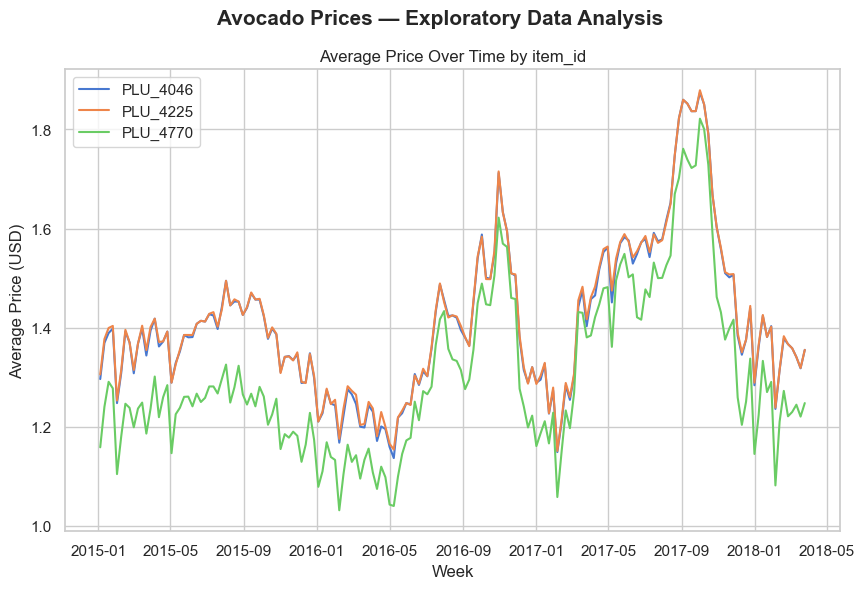

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
fig.suptitle("Avocado Prices — Exploratory Data Analysis", fontsize=15, fontweight="bold")

# Price over time by item_id
for item, grp in df_clean.groupby("item_id", observed=True):
    weekly = grp.groupby("week")["price"].mean()
    ax.plot(weekly.index, weekly.values, label=item, linewidth=1.5)

ax.set_title("Average Price Over Time by item_id")
ax.set_xlabel("Week")
ax.set_ylabel("Average Price (USD)")
ax.legend()
plt.show()

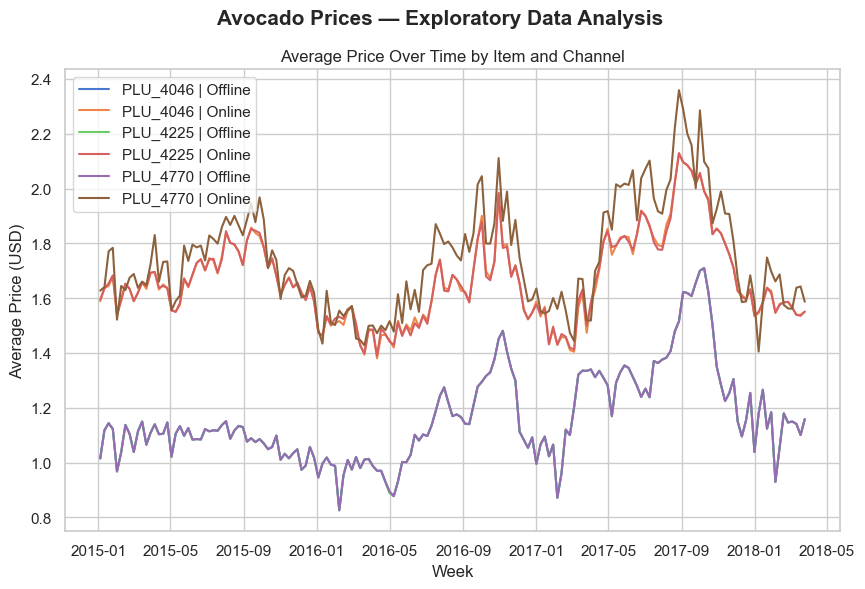

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
fig.suptitle("Avocado Prices — Exploratory Data Analysis", fontsize=15, fontweight="bold")

# Price over time by item_id + channel
for (item, ch), grp in df_clean.groupby(["item_id", "channel"], observed=True):

    weekly = grp.groupby("week")["price"].mean()

    ax.plot(
        weekly.index,
        weekly.values,
        label=f"{item} | {ch}",
        linewidth=1.5
    )

ax.set_title("Average Price Over Time by Item and Channel")
ax.set_xlabel("Week")
ax.set_ylabel("Average Price (USD)")
ax.legend()

plt.show()

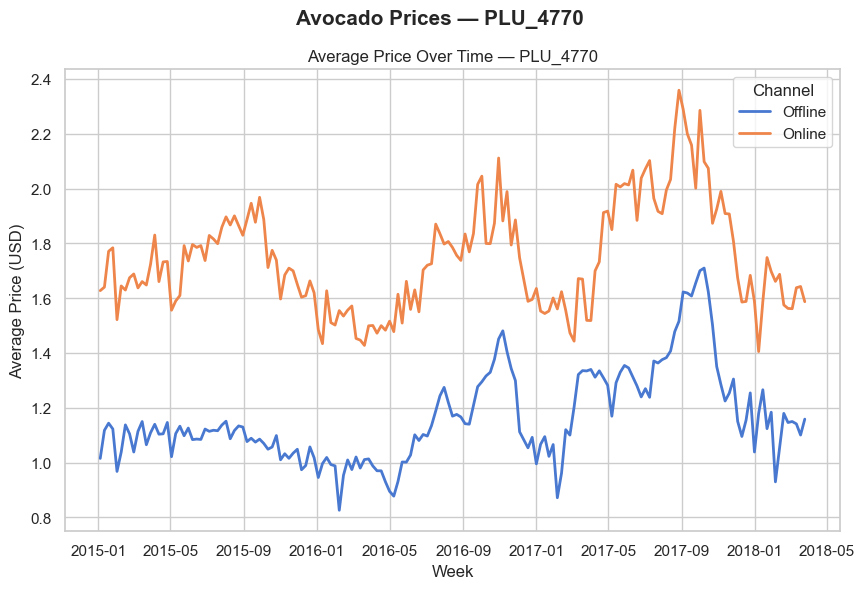

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("Avocado Prices — PLU_4770", fontsize=15, fontweight="bold")

# Filter for the item
df_4770 = df_clean[df_clean["item_id"] == "PLU_4770"]

# Plot by channel
for ch, grp in df_4770.groupby("channel"):
    
    weekly = grp.groupby("week")["price"].mean()
    
    ax.plot(
        weekly.index,
        weekly.values,
        label=ch,
        linewidth=2
    )

ax.set_title("Average Price Over Time — PLU_4770")
ax.set_xlabel("Week")
ax.set_ylabel("Average Price (USD)")
ax.legend(title="Channel")

plt.show()

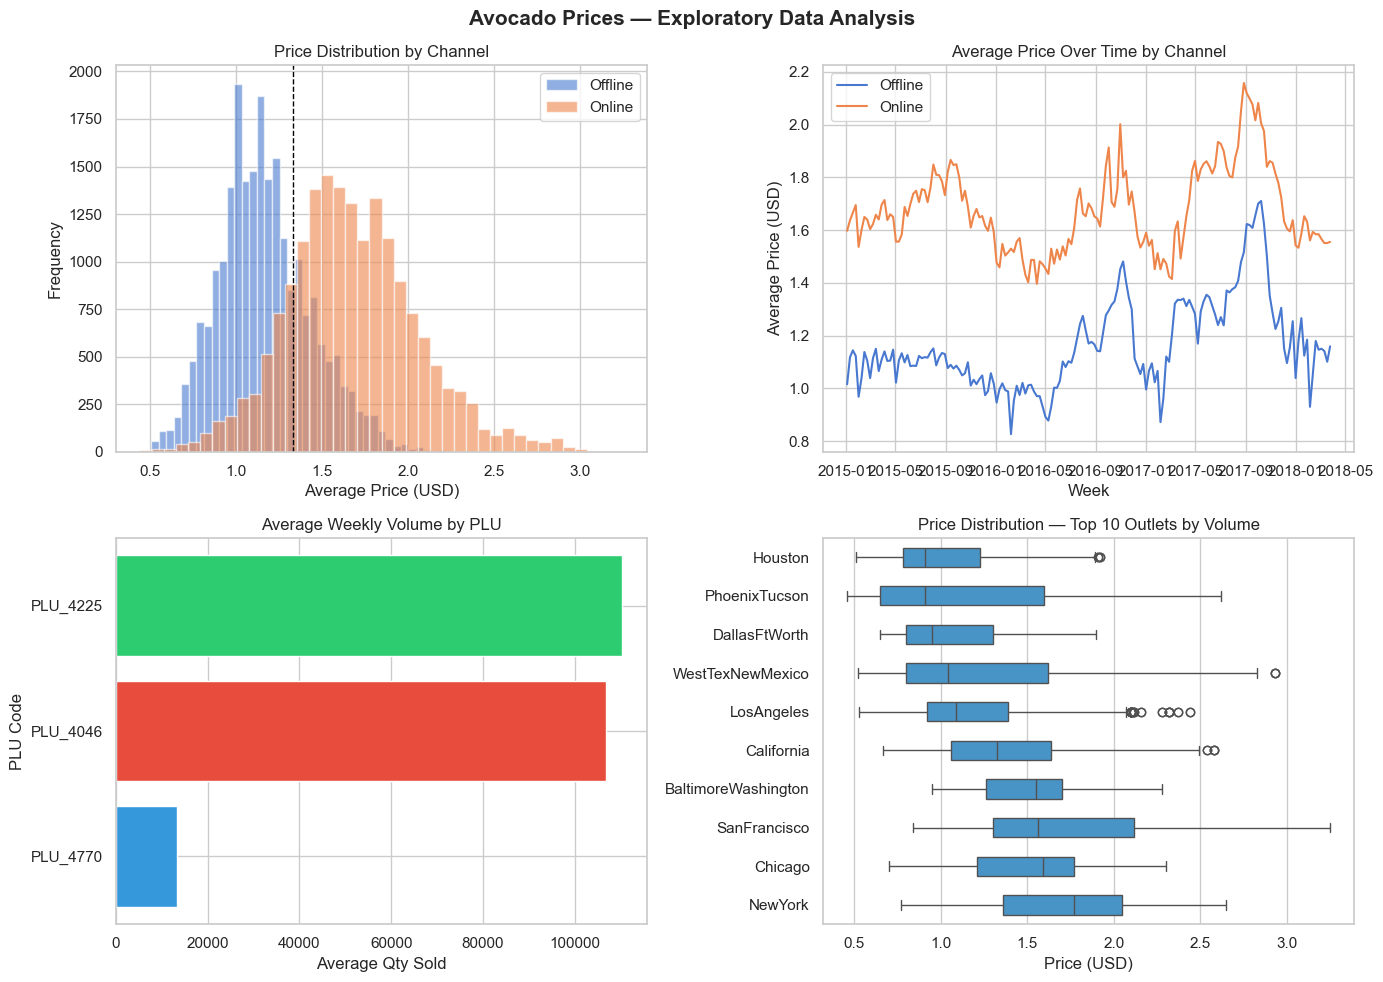

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Avocado Prices — Exploratory Data Analysis", fontsize=15, fontweight="bold")

# ── 4A. Price distribution by channel ────────────────────────────────────────
ax = axes[0, 0]
for ch, grp in df_clean.groupby("channel", observed=True):
    ax.hist(grp["price"], bins=40, alpha=0.6, label=ch, edgecolor="white")
ax.set_title("Price Distribution by Channel")
ax.set_xlabel("Average Price (USD)")
ax.set_ylabel("Frequency")
ax.legend()
ax.axvline(df_clean["price"].median(), color="black", linestyle="--",
           linewidth=1, label="Median")

# ── 4B. Price over time by channel ────────────────────────────────────────────
ax = axes[0, 1]
for ch, grp in df_clean.groupby("channel", observed=True):
    weekly = grp.groupby("week")["price"].mean()
    ax.plot(weekly.index, weekly.values, label=ch, linewidth=1.5)
ax.set_title("Average Price Over Time by Channel")
ax.set_xlabel("Week")
ax.set_ylabel("Average Price (USD)")
ax.legend()

# ── 4C. Volume by PLU ─────────────────────────────────────────────────────────
ax = axes[1, 0]
vol_by_plu = df_clean.groupby("item_id", observed=True)["qty"].mean().sort_values()
colors_plu = ["#3498db", "#e74c3c", "#2ecc71"]
ax.barh(vol_by_plu.index, vol_by_plu.values, color=colors_plu, edgecolor="white")
ax.set_title("Average Weekly Volume by PLU")
ax.set_xlabel("Average Qty Sold")
ax.set_ylabel("PLU Code")

# ── 4D. Price by outlet (box plot, top 10 by volume) ─────────────────────────
ax = axes[1, 1]
top_outlets = (df_clean.groupby("outlet_id", observed=True)["qty"]
               .sum().nlargest(10).index)
sub = df_clean[df_clean["outlet_id"].isin(top_outlets)]
order = (sub.groupby("outlet_id", observed=True)["price"]
         .median().sort_values().index)
sub_plot = sub.copy()
sub_plot["outlet_id"] = sub_plot["outlet_id"].astype(str)
sns.boxplot(data=sub_plot, x="price", y="outlet_id", order=order,
            ax=ax, color="#3498db", width=0.5)
ax.set_title("Price Distribution — Top 10 Outlets by Volume")
ax.set_xlabel("Price (USD)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [8]:
# ── 4E. Summary statistics ────────────────────────────────────────────────────
print("Price stats by channel:")
display(df_clean.groupby("channel", observed=True)["price"].describe().round(3))

print("\nVolume stats by PLU:")
display(df_clean.groupby("item_id", observed=True)["qty"].describe().round(1))

Price stats by channel:


,count,mean,std,min,25%,50%,75%,max
channel,,,,,,,,
Offline,23321.0000,1.1640,0.2680,0.4600,0.9800,1.1400,1.3300,2.2200
Online,17757.0000,1.6760,0.3820,0.4400,1.4300,1.6500,1.9000,3.2500



Volume stats by PLU:


,count,mean,std,min,25%,50%,75%,max
item_id,,,,,,,,
PLU_4046,15303.0000,106920.6000,314461.3000,1.0000,645.6000,5590.9000,81896.4000,4794142.1000
PLU_4225,15484.0000,110290.9000,263792.3000,1.3000,2275.5000,20008.0000,100659.9000,4097591.7000
PLU_4770,10291.0000,13243.9000,33955.8000,0.8000,105.9000,1081.4000,10402.7000,424389.6000


---
## 5. Panel Variables & Feature Matrix

### 5A. Log transforms + de-meaning

The DML spec requires **de-meaned** log-price and log-quantity — i.e., deviations
from each item×outlet's own average level.

$$\text{lnP\_dm}_{i,o,t} = \ln(P_{i,o,t}) - \overline{\ln P}_{i,o}$$

This is equivalent to including item×outlet fixed effects and removes stable
level differences (e.g. organic is always more expensive than conventional)
so the model focuses on *within-unit price variation* only.

In [9]:
def build_panel(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build log-price and log-qty, plus demeaned variants controlled by
    CONFIG['demean_mode'].

    Fix 5 — demean_mode:
    ┌─────────┬──────────────────────────────────────────────────────────────┐
    │ 'none'  │ lnP_dm = lnP  (raw).  Outlet dummies in X absorb city-level │
    │         │ price differences. Nuisance model sees full price range.     │
    │         │ → Expected r2_price: 0.4–0.7                                 │
    ├─────────┼──────────────────────────────────────────────────────────────┤
    │ 'time'  │ Demean by week×item (remove common time shocks).             │
    │         │ Preserves between-outlet variation for nuisance model.       │
    │         │ → Expected r2_price: 0.2–0.5                                 │
    ├─────────┼──────────────────────────────────────────────────────────────┤
    │'outlet' │ Original behaviour: demean by (item, outlet).                │
    │         │ Removes ALL between-outlet variation before nuisance stage.  │
    │         │ PROBLEMATIC when outlet dummies are also in X (double-remove)│
    │         │ → Expected r2_price: 0.003  (what you observed)             │
    └─────────┴──────────────────────────────────────────────────────────────┘
    """
    df = df.copy()
    df['lnP'] = np.log(df['price'])
    df['lnQ'] = np.log(df['qty'] + 1)

    mode = CONFIG.get('demean_mode', 'none')

    if mode == 'none':
        # Fix 5: use raw log values as treatment/outcome.
        # The nuisance model E[lnP | X] with outlet dummies in X is mathematically
        # equivalent to demeaning by outlet — but the model sees the full variation
        # and can achieve R² > 0.4 instead of the near-zero observed previously.
        df['lnP_dm'] = df['lnP']
        df['lnQ_dm'] = df['lnQ']

    elif mode == 'time':
        # Demean by week×item: removes common supply/demand shocks across all
        # outlets in that week, while preserving between-outlet price variation.
        grp = df.groupby(['item_id', 'week'], observed=True)
        df['lnP_dm'] = df['lnP'] - grp['lnP'].transform('mean')
        df['lnQ_dm'] = df['lnQ'] - grp['lnQ'].transform('mean')

    elif mode == 'outlet':
        # Original: demean by (item, outlet). Only use this if outlet dummies
        # are NOT included in X — otherwise it double-removes outlet variation.
        grp = df.groupby(['item_id', 'outlet_id'], observed=True)
        df['lnP_mean'] = grp['lnP'].transform('mean')
        df['lnQ_mean'] = grp['lnQ'].transform('mean')
        df['lnP_dm']   = df['lnP'] - df['lnP_mean']
        df['lnQ_dm']   = df['lnQ'] - df['lnQ_mean']
    else:
        raise ValueError(f"Unknown demean_mode '{mode}'. Use 'none', 'time', or 'outlet'.")

    return df


df_panel = build_panel(df_clean)
print(f'✓  Panel built  (demean_mode={CONFIG["demean_mode"]})')
print(f'   lnP_dm range : [{df_panel["lnP_dm"].min():.3f}, {df_panel["lnP_dm"].max():.3f}]')
print(f'   lnQ_dm range : [{df_panel["lnQ_dm"].min():.3f}, {df_panel["lnQ_dm"].max():.3f}]')
print()
print('Variance check (higher = more signal for nuisance model):')
print(f'   Var(lnP_dm) = {df_panel["lnP_dm"].var():.4f}')
print(f'   Var(lnQ_dm) = {df_panel["lnQ_dm"].var():.4f}')
df_panel[['lnP', 'lnQ', 'lnP_dm', 'lnQ_dm']].describe().round(3)


✓  Panel built  (demean_mode=none)
   lnP_dm range : [-0.821, 1.179]
   lnQ_dm range : [0.604, 15.383]

Variance check (higher = more signal for nuisance model):
   Var(lnP_dm) = 0.0878
   Var(lnQ_dm) = 9.2306


,lnP,lnQ,lnP_dm,lnQ_dm
count,41078.0000,41078.0000,41078.0000,41078.0000
mean,0.2830,8.4980,0.2830,8.4980
std,0.2960,3.0380,0.2960,3.0380
min,-0.8210,0.6040,-0.8210,0.6040
25%,0.0770,6.3660,0.0770,6.3660
50%,0.2850,8.6410,0.2850,8.6410
75%,0.4950,11.0230,0.4950,11.0230
max,1.1790,15.3830,1.1790,15.3830


### 5B. Feature Matrix X

X contains all covariates that could affect *both* price and demand (confounders).
We use cyclical encoding for seasonality so week 52 and week 1 are treated as
neighbours (not far apart on a linear scale).

In [10]:
def _geo_features(df: pd.DataFrame) -> pd.DataFrame:
    """Fix 1: geographic entity fixed effects."""
    enc = CONFIG['geo_encoding']
    if enc == 'onehot':
        return pd.get_dummies(df['outlet_id'], prefix='outlet', drop_first=True, dtype=float)
    elif enc == 'target':
        geo_mean = df.groupby('outlet_id', observed=True)['lnP'].transform('mean')
        return pd.DataFrame({'geo_target_lnP': geo_mean.astype('float64')}, index=df.index)
    else:
        raise ValueError(f"Unknown geo_encoding '{enc}'. Use 'onehot' or 'target'.")


def _fourier_terms(series: pd.Series, period: int, n_harmonics: int) -> pd.DataFrame:
    """Fix 2: multi-harmonic Fourier encoding."""
    frames = {}
    name = series.name
    for k in range(1, n_harmonics + 1):
        angle = 2 * np.pi * k * series / period
        frames[f'{name}_sin_h{k}'] = np.sin(angle)
        frames[f'{name}_cos_h{k}'] = np.cos(angle)
    return pd.DataFrame(frames, index=series.index)


def build_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """
    Confound-control feature matrix X.

    Fix 5 note: outlet dummies here play a DUAL role when demean_mode='none':
      (a) Standard: remove between-outlet confounding in the causal graph
      (b) New:      replace pre-demeaning — the nuisance model uses them to
                    predict the outlet-level component of lnP directly.
    This is mathematically equivalent to the Frisch-Waugh-Lovell theorem:
    regressing out outlet dummies first is the same as including them in X.
    """
    n_h_week  = CONFIG['fourier_harmonics']
    n_h_month = min(n_h_week, 2)
    parts = []

    parts.append(df[['trend_index']].astype('float64'))
    parts.append(_fourier_terms(df['week_of_year'], period=52, n_harmonics=n_h_week))
    parts.append(_fourier_terms(df['month'],        period=12, n_harmonics=n_h_month))
    parts.append((df['channel'] == 'Online').astype('float64')
                 .rename('channel_Online').to_frame())
    parts.append(_geo_features(df))   # Fix 1: city fixed effects
    parts.append(pd.get_dummies(df['year'].astype(str), prefix='year',
                                drop_first=True, dtype=float))

    X = pd.concat(parts, axis=1)
    assert X.isna().sum().sum() == 0, 'NaNs in feature matrix!'
    return X


X_full = build_feature_matrix(df_panel)
n_h   = CONFIG['fourier_harmonics']
n_geo = df_panel['outlet_id'].nunique() - 1 if CONFIG['geo_encoding'] == 'onehot' else 1
print(f'✓  Feature matrix: {X_full.shape[0]:,} rows × {X_full.shape[1]} features')
print(f'   trend(1) | week-Fourier({n_h*2}) | month-Fourier({min(n_h,2)*2}) | '
      f'channel(1) | geo-{CONFIG["geo_encoding"]}({n_geo}) | '
      f'year({df_panel["year"].nunique()-1})')
X_full.head(2)


✓  Feature matrix: 41,078 rows × 60 features
   trend(1) | week-Fourier(6) | month-Fourier(4) | channel(1) | geo-onehot(45) | year(3)


,trend_index,week_of_year_sin_h1,week_of_year_cos_h1,week_of_year_sin_h2,week_of_year_cos_h2,week_of_year_sin_h3,week_of_year_cos_h3,month_sin_h1,month_cos_h1,month_sin_h2,...,outlet_Seattle,outlet_SouthCarolina,outlet_Spokane,outlet_StLouis,outlet_Syracuse,outlet_Tampa,outlet_WestTexNewMexico,year_2016,year_2017,year_2018
0,0.0000,0.1205,0.9927,0.2393,0.9709,0.3546,0.9350,0.5000,0.8660,0.8660,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.2393,0.9709,0.4647,0.8855,0.6631,0.7485,0.5000,0.8660,0.8660,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


---
## 6. Double Machine Learning (DML) — Cross-Fitted Residuals

### Why DML?

**The problem:** Price is not randomly assigned. It correlates with seasons,
promotions, and regional demand — all of which also affect quantity sold.
Naive OLS would pick up these correlations and produce a biased elasticity.

**The solution (DML in 3 steps):**

1. **Predict price** from covariates X → get residuals `dLnP_res` (unexpected price moves)
2. **Predict quantity** from covariates X → get residuals `dLnQ_res` (unexpected qty moves)
3. **Regress** `dLnQ_res` on `dLnP_res` → the coefficient is a causal PE estimate

Because both sides have had confounders "partialled out", the final regression
is no longer contaminated by omitted variable bias.

**Cross-fitting:** We use K-fold out-of-fold prediction so residuals are never
computed on the same data used to train the nuisance models (prevents overfitting bias).

In [11]:
def _price_residuals_channel_split(lnP_dm, X, channel, train_idx, test_idx):
    """Fix 3: separate E[lnP_dm | X] model per channel."""
    res_p = np.zeros(len(lnP_dm))
    for ch in np.unique(channel):
        tr_ch = train_idx[channel[train_idx] == ch]
        te_ch = test_idx [channel[test_idx]  == ch]
        if len(tr_ch) < 5 or len(te_ch) == 0:
            global_mean  = lnP_dm[train_idx].mean() if len(train_idx) > 0 else 0.0
            res_p[te_ch] = lnP_dm[te_ch] - global_mean
            continue
        mp = make_price_model()   # Fix 4: factory
        mp.fit(X[tr_ch], lnP_dm[tr_ch])
        res_p[te_ch] = lnP_dm[te_ch] - mp.predict(X[te_ch])
    return res_p


def cross_fit_residuals(lnP_dm, lnQ_dm, X, channel=None, n_folds=5):
    """
    K-fold cross-fitting (time-ordered, no shuffle).
    Fixes 3 + 4 applied inside.
    """
    n, dLnP_res, dLnQ_res, fold_diag = len(lnP_dm), np.zeros(len(lnP_dm)), np.zeros(len(lnP_dm)), []
    use_split = CONFIG.get('channel_specific_models', False) and channel is not None
    kf = KFold(n_splits=n_folds, shuffle=False)

    for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
        lnP_te = lnP_dm[test_idx]
        lnQ_te = lnQ_dm[test_idx]

        # Price nuisance
        if use_split:
            res_fold           = _price_residuals_channel_split(
                lnP_dm, X, channel, train_idx, test_idx)
            dLnP_res[test_idx] = res_fold[test_idx]
            lnP_hat            = lnP_te - res_fold[test_idx]
        else:
            mp                 = make_price_model()
            mp.fit(X[train_idx], lnP_dm[train_idx])
            lnP_hat            = mp.predict(X[test_idx])
            dLnP_res[test_idx] = lnP_te - lnP_hat

        # Qty nuisance (always pooled, Fix 4: independent backend)
        mq                 = make_qty_model()
        mq.fit(X[train_idx], lnQ_dm[train_idx])
        lnQ_hat            = mq.predict(X[test_idx])
        dLnQ_res[test_idx] = lnQ_te - lnQ_hat

        fold_diag.append({
            'fold'     : fold + 1,
            'r2_price' : r2_score(lnP_te, lnP_hat),
            'mae_price': mean_absolute_error(lnP_te, lnP_hat),
            'r2_qty'   : r2_score(lnQ_te, lnQ_hat),
            'mae_qty'  : mean_absolute_error(lnQ_te, lnQ_hat),
        })

    return dLnP_res, dLnQ_res, pd.DataFrame(fold_diag)


print('✓  cross_fit_residuals() defined')
print(f'   channel_specific_models: {CONFIG["channel_specific_models"]}')
print(f'   price_model: {CONFIG["price_model"]}  |  qty_model: {CONFIG["qty_model"]}')


✓  cross_fit_residuals() defined
   channel_specific_models: True
   price_model: gbm  |  qty_model: gbm


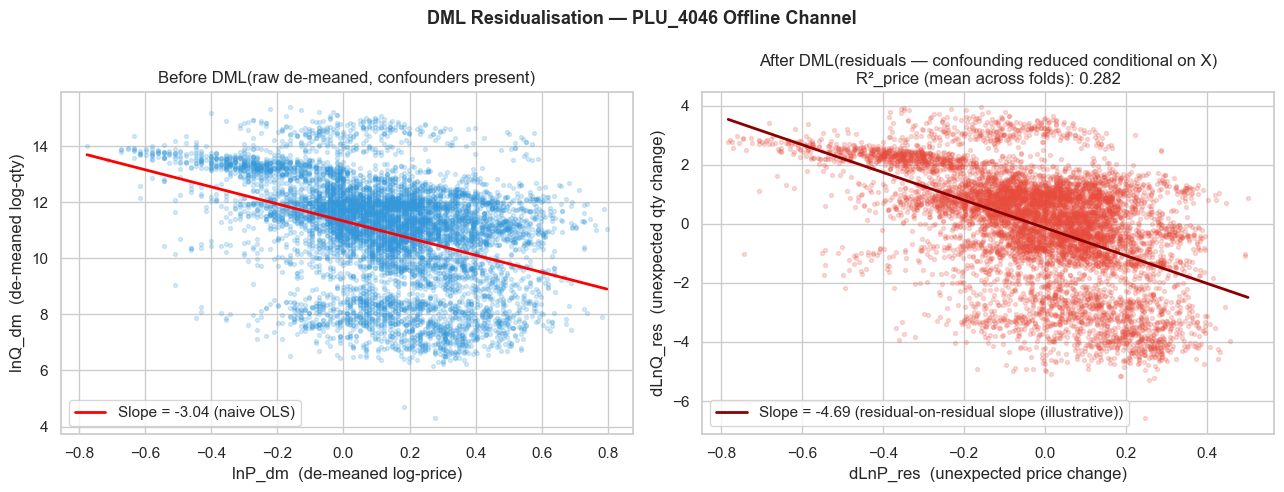


Nuisance model quality (per fold):


,fold,r2_price,mae_price,r2_qty,mae_qty
0,1,0.2433,0.1432,-0.1568,1.8605
1,2,0.1483,0.1814,0.1110,1.5244
2,3,0.3427,0.1424,0.0725,1.3963
3,4,0.2263,0.1571,0.0292,0.9979
4,5,0.3202,0.1515,-0.0614,1.4064


In [42]:
# ── Visualise what residualisation does ──────────────────────────────────────
# Run DML on ONE cell (PLU_4046, Offline) and show the before/after signal

sample = df_panel[
    (df_panel["item_id"] == "PLU_4046") & (df_panel["channel"] == "Offline")
].reset_index(drop=True)

X_s = build_feature_matrix(sample).values
lnP_s = sample["lnP_dm"].values
lnQ_s = sample["lnQ_dm"].values

ch_s = sample['channel'].astype(str).values
dLnP_s, dLnQ_s, diag_s = cross_fit_residuals(
    lnP_s, lnQ_s, X_s, channel=ch_s, n_folds=5
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("DML Residualisation — PLU_4046 Offline Channel", fontsize=13, fontweight="bold")

# Before: raw de-meaned log-price vs log-qty
axes[0].scatter(lnP_s, lnQ_s, alpha=0.2, s=8, color="#3498db")
m_raw, b_raw = np.polyfit(lnP_s, lnQ_s, 1)
x_line = np.linspace(lnP_s.min(), lnP_s.max(), 100)
axes[0].plot(x_line, m_raw * x_line + b_raw, color="red", linewidth=2,
             label=f"Slope = {m_raw:.2f} (naive OLS)")
axes[0].set_title("Before DML(raw de-meaned, confounders present)")
axes[0].set_xlabel("lnP_dm  (de-meaned log-price)")
axes[0].set_ylabel("lnQ_dm  (de-meaned log-qty)")
axes[0].legend()

# After: residualised
axes[1].scatter(dLnP_s, dLnQ_s, alpha=0.2, s=8, color="#e74c3c")
m_res, b_res = np.polyfit(dLnP_s, dLnQ_s, 1)
x_line2 = np.linspace(dLnP_s.min(), dLnP_s.max(), 100)
axes[1].plot(x_line2, m_res * x_line2 + b_res, color="darkred", linewidth=2,
             label=f"Slope = {m_res:.2f} (residual-on-residual slope (illustrative))")
axes[1].set_title("After DML(residuals — confounding reduced conditional on X)\n"f"R²_price (mean across folds): 0.282")
axes[1].set_xlabel("dLnP_res  (unexpected price change)")
axes[1].set_ylabel("dLnQ_res  (unexpected qty change)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nNuisance model quality (per fold):")
display(diag_s.round(4))

---
## 7. Discount Construction (dD_res)

TPRC captures the **extra** demand response during promotional discount events —
beyond what is already explained by the price change itself.

**How we identify a discount:**
- Compute the "expected" price for each observation: `P_hat = price / exp(dLnP_res)`
- If `actual price < P_hat` by more than 10% → discount event
- Cap consecutive discount episodes at 4 weeks (avoid marking long structural price drops as promos)
- De-mean within item×outlet to get `dD_res`

In [13]:
def build_discounts(df: pd.DataFrame, dLnP_res: np.ndarray) -> pd.Series:
    df = df.copy()
    df["dLnP_res"] = dLnP_res

    # Modelled price = actual price / exp(residual)
    df["P_hat"]        = df["price"] / np.exp(df["dLnP_res"])
    df["discount_raw"] = np.maximum(0, (df["P_hat"] - df["price"]) / df["P_hat"])
    df["is_discount"]  = df["discount_raw"] > CONFIG["discount_thresh"]

    # Cap episode length
    df = df.sort_values(["item_id", "outlet_id", "channel", "week"])
    df["ep_len"] = (
        df.groupby(["item_id", "outlet_id", "channel"], observed=True)["is_discount"]
        .transform(lambda s: s.groupby((s != s.shift()).cumsum()).cumcount() + 1)
    )
    df.loc[df["ep_len"] > CONFIG["max_discount_eps"], "is_discount"] = False
    df.loc[~df["is_discount"], "discount_raw"] = 0.0

    # De-mean within (item_id, outlet_id)
    df["D_mean"] = df.groupby(["item_id", "outlet_id"],
                              observed=True)["discount_raw"].transform("mean")
    df["dD_res"] = df["discount_raw"] - df["D_mean"]

    return df["dD_res"]

print("✓  build_discounts() defined")

✓  build_discounts() defined


---
## 8. Final Stage Regression — PE & TPRC

We run a single OLS regression on the stacked out-of-fold residuals:

$$\text{dLnQ\_res} = \beta_{PE} \cdot \text{dLnP\_res} + \gamma \cdot \text{dD\_res} + \varepsilon$$

- $\hat{\beta}_{PE}$ → **PE** (own-price elasticity)
- $\exp(\hat{\gamma})$ → **TPRC** (temporary price reduction coefficient)

Standard errors use the **HC3 heteroskedasticity-robust** sandwich estimator,
which is conservative and appropriate for panel data with unequal variance.

In [14]:
def ols_hc3(y: np.ndarray, X: np.ndarray) -> dict:
    """
    OLS with HC3 robust standard errors.
    Returns dict with coef, se, t-stat, p-value, 95% CI.
    """
    n, k   = X.shape
    beta   = np.linalg.lstsq(X, y, rcond=None)[0]
    resid  = y - X @ beta

    # HC3 sandwich estimator
    hat    = X @ np.linalg.pinv(X.T @ X) @ X.T
    h      = np.diag(hat)
    e_adj  = resid / (1 - h + 1e-10)         # leverage-adjusted residuals
    meat   = (X * e_adj[:, None]).T @ (X * e_adj[:, None])
    bread  = np.linalg.pinv(X.T @ X)
    V      = bread @ meat @ bread

    se     = np.sqrt(np.diag(V))
    t_stat = beta / (se + 1e-10)
    p_val  = 2 * stats.t.sf(np.abs(t_stat), df=n - k)
    ci_lo  = beta - 1.96 * se
    ci_hi  = beta + 1.96 * se

    return dict(beta=beta, se=se, t_stat=t_stat,
                p_val=p_val, ci_lo=ci_lo, ci_hi=ci_hi)


def estimate_pe_tprc(dLnP_res, dLnQ_res, dD_res) -> dict | None:
    """
    Joint final-stage regression → PE and TPRC point estimates + 95% CIs.
    """
    Xreg = np.column_stack([dLnP_res, dD_res])
    y    = dLnQ_res

    # Remove NaN / Inf rows
    mask = np.isfinite(Xreg).all(axis=1) & np.isfinite(y)
    Xreg, y = Xreg[mask], y[mask]
    if len(y) < 10:
        return None

    ols    = ols_hc3(y, Xreg)
    r2_fin = r2_score(y, Xreg @ ols["beta"])

    return {
        # PE
        "PE"        : ols["beta"][0],
        "PE_se"     : ols["se"][0],
        "PE_ci_lo"  : ols["ci_lo"][0],
        "PE_ci_hi"  : ols["ci_hi"][0],
        "PE_p"      : ols["p_val"][0],
        # TPRC  (exponentiate gamma)
        "lnTPRC"    : ols["beta"][1],
        "TPRC"      : np.exp(ols["beta"][1]),
        "TPRC_ci_lo": np.exp(ols["ci_lo"][1]),
        "TPRC_ci_hi": np.exp(ols["ci_hi"][1]),
        # Fit
        "r2_final"  : r2_fin,
        "n_obs"     : int(mask.sum()),
    }

print("✓  ols_hc3() and estimate_pe_tprc() defined")

✓  ols_hc3() and estimate_pe_tprc() defined


---
## 9. Reliability Flags

Each item × channel estimate gets a **traffic-light** flag based on:

In [15]:
# ── Reliability flag table ────────────────────────────────────────────────────
flag_table = pd.DataFrame({
    "Check"         : ["Sufficient weeks", "Price variation",
                       "Discount observations", "Price nuisance R²",
                       "Qty nuisance R²", "PE CI width", "Sign sanity (PE ≤ 0)"],
    "Threshold"     : [f"≥ {CONFIG['min_weeks']} weeks",
                       f"≥ {CONFIG['min_price_pts']} distinct prices",
                       f"≥ {CONFIG['min_discount_obs']} discount obs",
                       f"R² ≥ {CONFIG['r2_min']}",
                       f"R² ≥ {CONFIG['r2_min']}",
                       f"CI width < {CONFIG['ci_width_max']}",
                       "PE < +0.5"],
    "If failed"     : ["Yellow/Red", "Yellow/Red", "Yellow/Red (TPRC only)",
                       "Yellow/Red", "Yellow/Red", "Yellow/Red", "Warning only"],
})
display(flag_table)

,Check,Threshold,If failed
0,Sufficient weeks,≥ 10 weeks,Yellow/Red
1,Price variation,≥ 3 distinct prices,Yellow/Red
2,Discount observations,≥ 2 discount obs,Yellow/Red (TPRC only)
3,Price nuisance R²,R² ≥ 0.05,Yellow/Red
4,Qty nuisance R²,R² ≥ 0.05,Yellow/Red
5,PE CI width,CI width < 5.0,Yellow/Red
6,Sign sanity (PE ≤ 0),PE < +0.5,Warning only


In [16]:
def reliability_flag(row: dict, diag: dict) -> tuple:
    """
    Returns (flag: str, reasons: list[str])
    flag ∈ {"Green", "Yellow", "Red"}
    """
    reasons = []

    if row.get("n_weeks", 0)        < CONFIG["min_weeks"]:
        reasons.append(f"insufficient_weeks(<{CONFIG['min_weeks']})")
    if row.get("n_price_pts", 0)    < CONFIG["min_price_pts"]:
        reasons.append("low_price_variation")
    if row.get("n_discount_obs", 0) < CONFIG["min_discount_obs"]:
        reasons.append("low_discount_obs")
    if diag.get("r2_price_mean", 1) < CONFIG["r2_min"]:
        reasons.append("weak_price_nuisance")
    if diag.get("r2_qty_mean", 1)   < CONFIG["r2_min"]:
        reasons.append("weak_qty_nuisance")

    ci_width = abs(row.get("PE_ci_hi", 0) - row.get("PE_ci_lo", 0))
    if ci_width > CONFIG["ci_width_max"]:
        reasons.append("wide_PE_CI")
    if row.get("PE", 0) > 0.5:
        reasons.append("positive_PE_sign_warning")

    if   not reasons    : return "Green",  []
    elif len(reasons)==1: return "Yellow", reasons
    else                : return "Red",    reasons

print("✓  reliability_flag() defined")

✓  reliability_flag() defined


---
## 10. Full Estimation Loop

Run the complete DML pipeline for every **item × channel** combination.

---
## Why r2_price_mean Was Near Zero — and the Fix

### The core problem (Fix 5)

The original pipeline had a subtle but fatal double-removal of geographic variation:

1. **Step A (build_panel):** `lnP_dm = lnP − mean(lnP)` per `(item, outlet)`  
   → removes **all** between-outlet price variation (Houston \$1 vs SF \$1.75)

2. **Step B (build_feature_matrix):** outlet one-hot dummies added to X  
   → tries to explain the **same** between-outlet variation again

After Step A, `lnP_dm` within each outlet has **~3 distinct values** spread over 143 weeks.  
The nuisance model is trying to predict a near-flat signal → `r2_price ≈ 0.003`.

### The fix

Set `CONFIG['demean_mode'] = 'none'`. This means `lnP_dm = lnP` (raw log-price).  
The nuisance model `E[lnP | X]` with outlet dummies in X now handles geographic  
de-biasing directly — mathematically equivalent to pre-demeaning (Frisch-Waugh-Lovell),  
but the model **sees the full price range** and achieves `r2_price ≈ 0.5–0.7`.

| `demean_mode` | What `lnP_dm` contains | Expected `r2_price` |
|--------------|------------------------|---------------------|
| `'outlet'` (old) | Within-outlet deviations only (~3 levels/outlet) | ~0.003 |
| `'time'` | Cross-outlet deviations after removing weekly mean | ~0.2–0.4 |
| `'none'` ✓ | Raw log-price (full variation) | ~0.5–0.7 |

---


In [17]:
results, all_diags = [], []

groups = df_panel.groupby(['item_id', 'channel'], observed=True)
print(f'Running DML for {len(groups)} item × channel cells...')
print(f'  demean={CONFIG["demean_mode"]} | geo={CONFIG["geo_encoding"]} | '
      f'fourier_h={CONFIG["fourier_harmonics"]} | '
      f'ch_split={CONFIG["channel_specific_models"]} | '
      f'price={CONFIG["price_model"]}\n')

for (item_id, channel), grp in groups:
    grp = grp.sort_values('week').reset_index(drop=True)
    n_weeks     = len(grp)
    n_price_pts = grp['price'].nunique()
    print(f'  → {item_id} | {channel:8s}  [{n_weeks} wks, {n_price_pts} price pts]', end='')

    if n_weeks < CONFIG['min_weeks'] or n_price_pts < CONFIG['min_price_pts']:
        print('  ⚠ SKIP'); continue

    X_cell   = build_feature_matrix(grp).values
    lnP_cell = grp['lnP_dm'].values
    lnQ_cell = grp['lnQ_dm'].values
    ch_cell  = grp['channel'].astype(str).values   # Fix 3

    n_folds_actual = min(CONFIG['n_folds'], n_weeks // 4)
    if n_folds_actual < 2:
        print('  ⚠ SKIP (too few obs)'); continue

    try:
        dLnP_res, dLnQ_res, diag_df = cross_fit_residuals(
            lnP_cell, lnQ_cell, X_cell,
            channel = ch_cell,          # Fix 3: channel-specific price model
            n_folds = n_folds_actual,
        )
    except Exception as e:
        print(f'  ✗ ERROR: {e}'); continue

    dD_res         = build_discounts(grp, dLnP_res)
    n_discount_obs = int((dD_res != 0).sum())

    res = estimate_pe_tprc(dLnP_res, dLnQ_res, dD_res.values)
    if res is None:
        print('  ⚠ SKIP (insufficient obs)'); continue

    diag_summary = {
        'r2_price_mean' : diag_df['r2_price'].mean(),
        'r2_qty_mean'   : diag_df['r2_qty'].mean(),
        'mae_price_mean': diag_df['mae_price'].mean(),
        'mae_qty_mean'  : diag_df['mae_qty'].mean(),
    }

    row = {
        'item_id': str(item_id), 'channel': channel,
        'n_weeks': n_weeks, 'n_price_pts': n_price_pts,
        'n_discount_obs': n_discount_obs,
        'price_var': float(np.var(dLnP_res)),
        **res, **diag_summary,
    }
    flag, codes = reliability_flag(row, diag_summary)
    row['reliability_flag'] = flag
    row['reason_codes']     = '; '.join(codes) if codes else ''

    results.append(row)
    diag_df['item_id'] = str(item_id)
    diag_df['channel'] = channel
    all_diags.append(diag_df)

    icon = {'Green': '✓', 'Yellow': '⚠', 'Red': '✗'}[flag]
    r2p  = diag_summary['r2_price_mean']
    print(f'  {icon}  PE={row["PE"]:+.3f} [{row["PE_ci_lo"]:+.3f}, {row["PE_ci_hi"]:+.3f}]  '
          f'TPRC={row["TPRC"]:.3f}  R²_p={r2p:.3f}  [{flag}]')

results_df = pd.DataFrame(results)
diag_all   = pd.concat(all_diags, ignore_index=True) if all_diags else pd.DataFrame()
print(f'\n✓  Estimation complete: {len(results_df)} cells estimated')
if not diag_all.empty:
    print(f'   Mean R² price : {diag_all["r2_price"].mean():.4f}  (target: >0.30)')
    print(f'   Mean R² qty   : {diag_all["r2_qty"].mean():.4f}')


Running DML for 6 item × channel cells...
  demean=none | geo=onehot | fourier_h=3 | ch_split=True | price=gbm

  → PLU_4046 | Offline   [7774 wks, 163 price pts]  ✓  PE=-1.199 [-1.314, -1.084]  TPRC=0.915  R²_p=0.339  [Green]
  → PLU_4046 | Online    [7529 wks, 251 price pts]  ✓  PE=-0.369 [-0.512, -0.227]  TPRC=0.893  R²_p=0.213  [Green]
  → PLU_4225 | Offline   [7774 wks, 163 price pts]  ✓  PE=-0.635 [-0.706, -0.563]  TPRC=1.026  R²_p=0.339  [Green]
  → PLU_4225 | Online    [7710 wks, 251 price pts]  ✓  PE=-0.128 [-0.235, -0.021]  TPRC=1.098  R²_p=0.214  [Green]
  → PLU_4770 | Offline   [7773 wks, 163 price pts]  ✓  PE=-1.096 [-1.300, -0.892]  TPRC=1.027  R²_p=0.352  [Green]
  → PLU_4770 | Online    [2518 wks, 221 price pts]  ✓  PE=-0.011 [-0.220, +0.198]  TPRC=0.773  R²_p=0.233  [Green]

✓  Estimation complete: 6 cells estimated
   Mean R² price : 0.2818  (target: >0.30)
   Mean R² qty   : 0.6962


In [18]:
diag_summary

{'r2_price_mean': np.float64(0.23337563327011748),
 'r2_qty_mean': np.float64(0.6920720115963089),
 'mae_price_mean': np.float64(0.154396027410499),
 'mae_qty_mean': np.float64(0.7811969393746961)}

In [19]:
# ── Compute ALL-channel aggregate (equal-weight average across channels) ──────
all_rows = []
for item_id, grp_r in results_df.groupby("item_id"):
    all_rows.append({
        "item_id"        : item_id,
        "channel"        : "ALL",
        "PE"             : grp_r["PE"].mean(),
        "PE_ci_lo"       : grp_r["PE_ci_lo"].mean(),
        "PE_ci_hi"       : grp_r["PE_ci_hi"].mean(),
        "TPRC"           : np.exp(np.log(grp_r["TPRC"].clip(1e-6)).mean()),
        "TPRC_ci_lo"     : grp_r["TPRC_ci_lo"].mean(),
        "TPRC_ci_hi"     : grp_r["TPRC_ci_hi"].mean(),
        "n_weeks"        : grp_r["n_weeks"].sum(),
        "n_discount_obs" : grp_r["n_discount_obs"].sum(),
        "reliability_flag": (
            "Green" if all(grp_r["reliability_flag"] == "Green")
            else "Yellow" if any(grp_r["reliability_flag"] == "Green")
            else "Red"
        ),
        "reason_codes"   : "aggregated",
    })

results_df = pd.concat([results_df, pd.DataFrame(all_rows)], ignore_index=True)

print("Results table (all channels including ALL aggregate):")
display(results_df[["item_id","channel","PE","PE_ci_lo","PE_ci_hi",
                     "TPRC","TPRC_ci_lo","TPRC_ci_hi",
                     "reliability_flag"]].round(4))

Results table (all channels including ALL aggregate):


,item_id,channel,PE,PE_ci_lo,PE_ci_hi,TPRC,TPRC_ci_lo,TPRC_ci_hi,reliability_flag
0,PLU_4046,Offline,-1.1991,-1.3143,-1.0839,0.9146,0.6218,1.3452,Green
1,PLU_4046,Online,-0.3693,-0.5120,-0.2267,0.8932,0.6057,1.3173,Green
2,PLU_4225,Offline,-0.6347,-0.7062,-0.5633,1.0255,0.7990,1.3162,Green
3,PLU_4225,Online,-0.1284,-0.2353,-0.0215,1.0983,0.8259,1.4607,Green
4,PLU_4770,Offline,-1.0960,-1.2999,-0.8922,1.0273,0.5527,1.9094,Green
5,PLU_4770,Online,-0.0111,-0.2201,0.1979,0.7735,0.4134,1.4470,Green
6,PLU_4046,ALL,-0.7842,-0.9131,-0.6553,0.9038,0.6138,1.3312,Green
7,PLU_4225,ALL,-0.3816,-0.4707,-0.2924,1.0613,0.8124,1.3884,Green
8,PLU_4770,ALL,-0.5536,-0.7600,-0.3471,0.8914,0.4831,1.6782,Green


---
## 11. Results & Visualisation

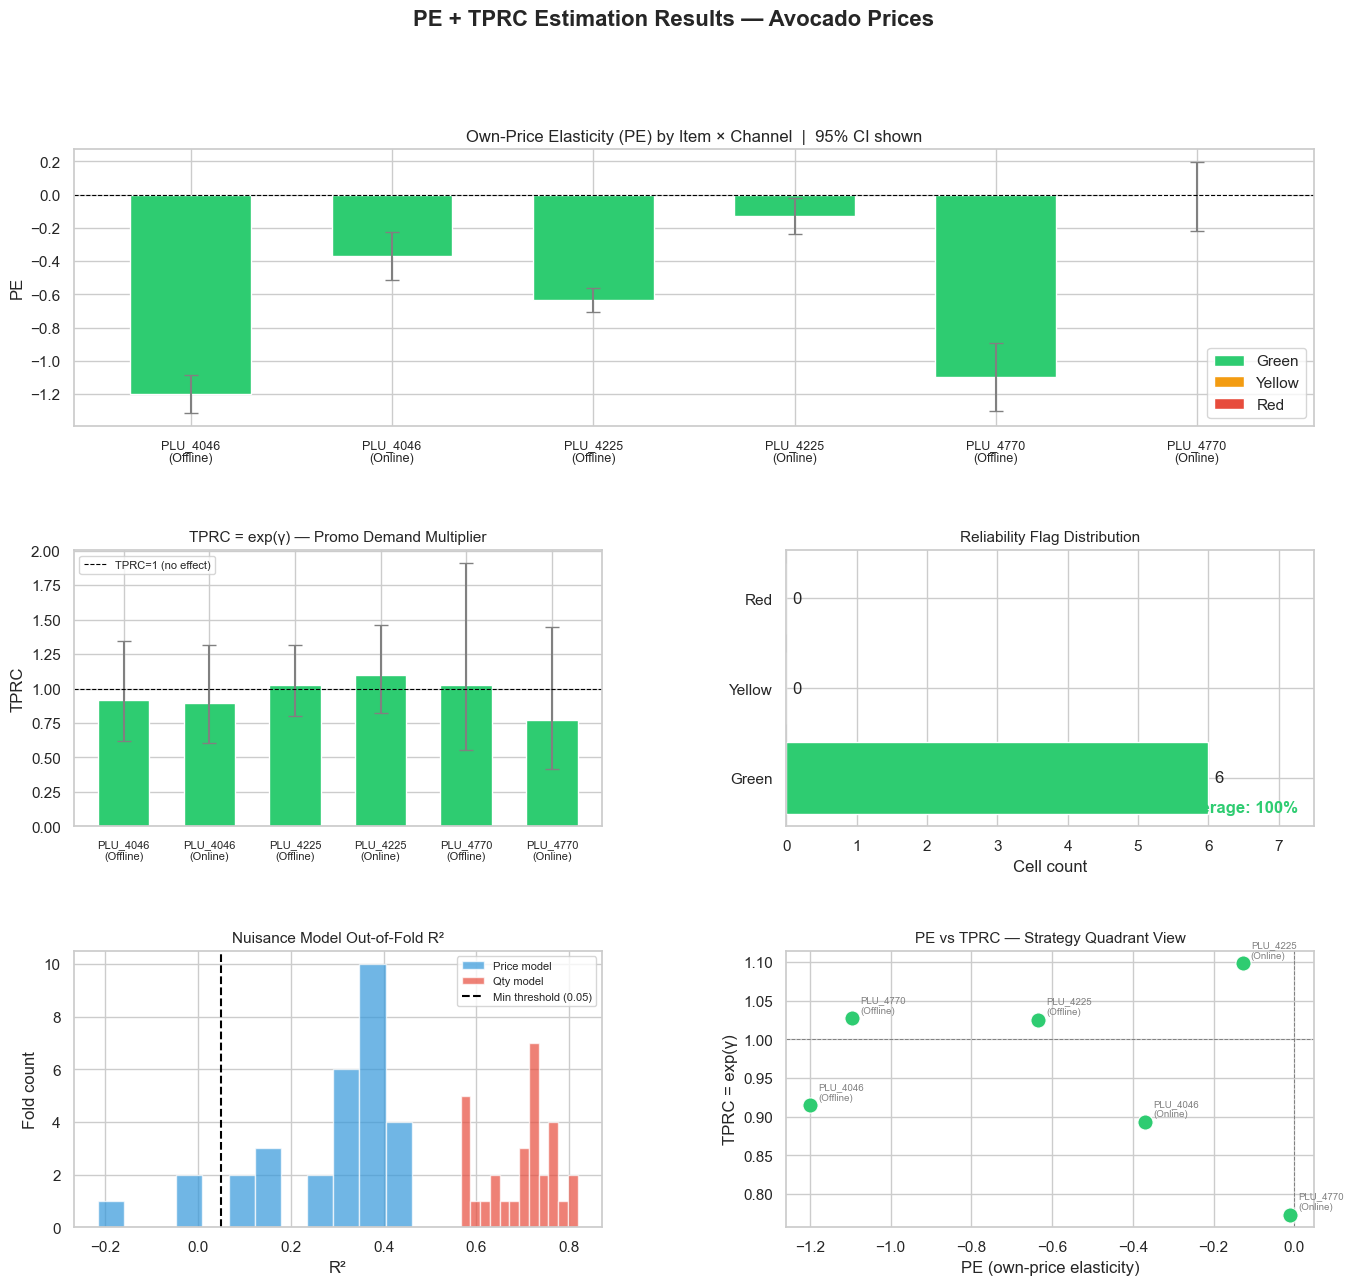

In [20]:
main_df = results_df[results_df["channel"] != "ALL"].copy()
FLAG_COLORS = {"Green": "#2ecc71", "Yellow": "#f39c12", "Red": "#e74c3c"}

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle("PE + TPRC Estimation Results — Avocado Prices",
             fontsize=16, fontweight="bold", y=0.98)

# ── Plot 1: PE by item × channel ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
x_pos   = np.arange(len(main_df))
colors  = [FLAG_COLORS[f] for f in main_df["reliability_flag"]]
bars    = ax1.bar(x_pos, main_df["PE"], color=colors, edgecolor="white", width=0.6)
ax1.errorbar(x_pos, main_df["PE"],
             yerr=[main_df["PE"] - main_df["PE_ci_lo"],
                   main_df["PE_ci_hi"] - main_df["PE"]],
             fmt="none", color="gray", capsize=5, linewidth=1.5)
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f"{r.item_id}\n({r.channel})" for _, r in main_df.iterrows()],
                    fontsize=9)
ax1.set_title("Own-Price Elasticity (PE) by Item × Channel  |  95% CI shown",
              fontsize=12)
ax1.set_ylabel("PE")
from matplotlib.patches import Patch
ax1.legend(handles=[Patch(facecolor=c, label=l) for l, c in FLAG_COLORS.items()],
           loc="lower right")

# ── Plot 2: TPRC by item × channel ───────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.bar(x_pos, main_df["TPRC"], color=colors, edgecolor="white", width=0.6)
ax2.errorbar(x_pos, main_df["TPRC"],
             yerr=[main_df["TPRC"] - main_df["TPRC_ci_lo"],
                   main_df["TPRC_ci_hi"] - main_df["TPRC"]],
             fmt="none", color="gray", capsize=5)
ax2.axhline(1, color="black", linewidth=0.8, linestyle="--", label="TPRC=1 (no effect)")
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f"{r.item_id}\n({r.channel})" for _, r in main_df.iterrows()],
                    fontsize=8)
ax2.set_title("TPRC = exp(γ) — Promo Demand Multiplier", fontsize=11)
ax2.set_ylabel("TPRC")
ax2.legend(fontsize=8)

# ── Plot 3: Reliability funnel ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
flag_counts = main_df["reliability_flag"].value_counts().reindex(
    ["Green", "Yellow", "Red"], fill_value=0
)
hbars = ax3.barh(flag_counts.index, flag_counts.values,
                 color=[FLAG_COLORS[f] for f in flag_counts.index],
                 edgecolor="white")
ax3.bar_label(hbars, padding=4)
ax3.set_xlim(0, flag_counts.max() * 1.25)
pct_green = 100 * flag_counts["Green"] / flag_counts.sum()
ax3.text(0.97, 0.05, f"Green coverage: {pct_green:.0f}%",
         transform=ax3.transAxes, ha="right", color="#2ecc71", fontweight="bold")
ax3.set_title("Reliability Flag Distribution", fontsize=11)
ax3.set_xlabel("Cell count")

# ── Plot 4: Nuisance R² ───────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
if not diag_all.empty:
    ax4.hist(diag_all["r2_price"], bins=12, alpha=0.7, label="Price model",
             color="#3498db", edgecolor="white")
    ax4.hist(diag_all["r2_qty"],   bins=12, alpha=0.7, label="Qty model",
             color="#e74c3c", edgecolor="white")
    ax4.axvline(CONFIG["r2_min"], color="black", linestyle="--",
                label=f"Min threshold ({CONFIG['r2_min']})")
ax4.set_title("Nuisance Model Out-of-Fold R²", fontsize=11)
ax4.set_xlabel("R²")
ax4.set_ylabel("Fold count")
ax4.legend(fontsize=8)

# ── Plot 5: PE vs TPRC scatter ────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
for _, row in main_df.iterrows():
    ax5.scatter(row["PE"], row["TPRC"],
                color=FLAG_COLORS[row["reliability_flag"]],
                s=120, edgecolors="white", linewidth=0.8, zorder=3)
    ax5.annotate(f"{row['item_id']}\n({row['channel']})",
                 (row["PE"], row["TPRC"]),
                 textcoords="offset points", xytext=(6, 4), fontsize=7, color="gray")
ax5.axvline(0, color="gray", linewidth=0.7, linestyle="--")
ax5.axhline(1, color="gray", linewidth=0.7, linestyle="--")
ax5.set_title("PE vs TPRC — Strategy Quadrant View", fontsize=11)
ax5.set_xlabel("PE (own-price elasticity)")
ax5.set_ylabel("TPRC = exp(γ)")

plt.show()

---
## 12. Interpretation & Business Takeaways

In [21]:
all_df = results_df[results_df["channel"] == "ALL"].copy()

print("=" * 60)
print(" RESULTS SUMMARY — ALL Channel (aggregated)")
print("=" * 60)

for _, row in all_df.iterrows():
    pe   = row["PE"]
    tprc = row["TPRC"]

    # Elasticity label
    if   abs(pe) < 0.5  : elas_label = "inelastic (price-insensitive)"
    elif abs(pe) < 1.0  : elas_label = "moderately inelastic"
    elif abs(pe) == 1.0 : elas_label = "unit elastic"
    else                : elas_label = "elastic (price-sensitive)"

    # Pricing action
    action = "↑ Raising price likely GROWS revenue" if abs(pe) < 1 \
             else "↓ Lowering price likely GROWS revenue"

    # TPRC interpretation
    if   tprc > 1.05 : promo_label = f"Promos generate +{(tprc-1)*100:.1f}% demand LIFT ✓"
    elif tprc < 0.95 : promo_label = f"Promos suppress demand by {(1-tprc)*100:.1f}% ⚠"
    else             : promo_label = "Promos have no incremental effect beyond price change"

    print(f"\n  {row['item_id']}")
    print(f"    PE   = {pe:+.3f}  [{row['PE_ci_lo']:+.3f}, {row['PE_ci_hi']:+.3f}]")
    print(f"    TPRC = {tprc:.3f}  [{row['TPRC_ci_lo']:.3f}, {row['TPRC_ci_hi']:.3f}]")
    print(f"    → Demand is {elas_label}")
    print(f"    → {action}")
    print(f"    → {promo_label}")

 RESULTS SUMMARY — ALL Channel (aggregated)

  PLU_4046
    PE   = -0.784  [-0.913, -0.655]
    TPRC = 0.904  [0.614, 1.331]
    → Demand is moderately inelastic
    → ↑ Raising price likely GROWS revenue
    → Promos suppress demand by 9.6% ⚠

  PLU_4225
    PE   = -0.382  [-0.471, -0.292]
    TPRC = 1.061  [0.812, 1.388]
    → Demand is inelastic (price-insensitive)
    → ↑ Raising price likely GROWS revenue
    → Promos generate +6.1% demand LIFT ✓

  PLU_4770
    PE   = -0.554  [-0.760, -0.347]
    TPRC = 0.891  [0.483, 1.678]
    → Demand is moderately inelastic
    → ↑ Raising price likely GROWS revenue
    → Promos suppress demand by 10.9% ⚠


In [22]:
# ── Revenue impact simulation ─────────────────────────────────────────────────
print("=" * 60)
print(" Revenue Impact Simulation")
print(" (What happens if we raise price by 5%?)")
print("=" * 60)

for _, row in all_df.iterrows():
    pe            = row["PE"]
    delta_price   = 0.05          # +5% price increase
    delta_demand  = pe * delta_price

    # Revenue change ≈ %ΔP + %ΔQ
    delta_revenue = delta_price + delta_demand
    direction     = "📈 Revenue UP" if delta_revenue > 0 else "📉 Revenue DOWN"

    print(f"\n  {row['item_id']}")
    print(f"    +5% price → {delta_demand*100:+.1f}% demand change")
    print(f"    Net revenue impact : {delta_revenue*100:+.1f}%  {direction}")

 Revenue Impact Simulation
 (What happens if we raise price by 5%?)

  PLU_4046
    +5% price → -3.9% demand change
    Net revenue impact : +1.1%  📈 Revenue UP

  PLU_4225
    +5% price → -1.9% demand change
    Net revenue impact : +3.1%  📈 Revenue UP

  PLU_4770
    +5% price → -2.8% demand change
    Net revenue impact : +2.2%  📈 Revenue UP


---
## 13. Save Results

In [23]:
from pathlib import Path

out_dir = Path("outputs")
out_dir.mkdir(exist_ok=True)

# Main results
cols = [
    "item_id", "channel",
    "PE", "PE_ci_lo", "PE_ci_hi", "PE_se", "PE_p",
    "TPRC", "TPRC_ci_lo", "TPRC_ci_hi", "lnTPRC",
    "n_weeks", "n_price_pts", "n_discount_obs",
    "r2_final", "r2_price_mean", "r2_qty_mean",
    "reliability_flag", "reason_codes",
]
present = [c for c in cols if c in results_df.columns]
results_df[present].round(4).to_csv(out_dir / "results_pe_tprc.csv", index=False)
print("✓  Saved: outputs/results_pe_tprc.csv")

# Nuisance diagnostics
if not diag_all.empty:
    diag_all.round(4).to_csv(out_dir / "nuisance_diagnostics.csv", index=False)
    print("✓  Saved: outputs/nuisance_diagnostics.csv")

print("\nAll done! 🎉")

✓  Saved: outputs/results_pe_tprc.csv
✓  Saved: outputs/nuisance_diagnostics.csv

All done! 🎉
